
<div dir=ltr align=center>

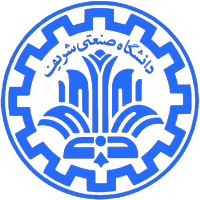

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 5<br>
    MDP<br>
<font color=696880 size=4>
    Erfan Bohloul

____

`Full Name: Mohsen Salah`

`Student ID: 403106238`

# Arash's decision

## Part 1

in this assignment, you will implement policy iteration to solve a classic problem. in this problem in addition to transition function, the reward function will be stochastic as well.

Now that the economy is a mess, Arash has left his noble job as a teacher and works at a car rental company. Arash is in charge of two garages. Each day, some number of customers come to the garages to rent cars. If Arash has a car available at the garage, he rents it out for 10 Rials. If there are no cars at the garage, he loses the customer!

Every day, a number of customers also return their rented cars, but these cars are not ready to be rented again until the next day.

To provide better service, Arash must ensure there are enough cars at both garages. That's why, each night, Arash can transfer some cars from one garage to the other.

Each night, at most 5 cars can be moved, and the cost of moving each car is 2 Rials.

Assume that the number of daily rental requests and car returns at each garage are drawn from a Poisson probability distribution. The probability that the number is $n$ is given by:

$$P(n) = \frac{\lambda^n e^{-\lambda}}{n!}$$

Suppose $\lambda = 3$ for rental requests at the first garage, $\lambda = 4$ for rental requests at the second garage, $\lambda = 3$ for returns at the first garage, and $\lambda = 2$ for returns at the second garage.

To simplify the problem, we assume that there can be no more than 20 cars at each location (any additional cars are returned to the car rental company, and thus disappear from the problem).

Take the discount rate to be $\gamma = 0.9$.

You can calculate Poisson probabilities up to $n = 11$.

Plot your results using plot_policy and plot_value_function functions.

In [62]:
import numpy as np
import math

In [63]:
poisson_cache = {}

def poisson_prob(n, lam):
    key = (n, lam)
    if key not in poisson_cache:
        poisson_cache[key] = math.exp(-lam) * lam**n / math.factorial(n)
    return poisson_cache[key]


In [64]:
MAX_CARS = 20
MOVE_COST = 2
RENTAL_REWARD = 10
GAMMA = 0.9
MAX_MOVE = 5
N_POISSON = 12

def expected_return(state: tuple, action: int, V):
    c1, c2 = state
    c1_new = np.clip(c1 - action, 0, MAX_CARS)
    c2_new = np.clip(c2 + action, 0, MAX_CARS)
    cost = abs(action) * MOVE_COST

    expected = 0.0

    r1 = np.arange(N_POISSON)
    r2 = np.arange(N_POISSON)
    e1 = np.arange(N_POISSON)
    e2 = np.arange(N_POISSON)

    p_r1 = np.array([poisson_prob(n, 3) for n in r1])
    p_r2 = np.array([poisson_prob(n, 4) for n in r2])
    p_e1 = np.array([poisson_prob(n, 3) for n in e1])
    p_e2 = np.array([poisson_prob(n, 2) for n in e2])

    rent1 = np.minimum(r1[:, None, None, None], c1_new)
    rent2 = np.minimum(r2[None, :, None, None], c2_new)
    c1_next = np.minimum(c1_new - rent1 + e1[None, None, :, None], MAX_CARS)
    c2_next = np.minimum(c2_new - rent2 + e2[None, None, None, :], MAX_CARS)

    income = (rent1 + rent2) * RENTAL_REWARD
    prob = (
        p_r1[:, None, None, None]
        * p_r2[None, :, None, None]
        * p_e1[None, None, :, None]
        * p_e2[None, None, None, :]
    )

    expected = float(np.sum(prob * (income + GAMMA * V[c1_next, c2_next])))
    return expected - cost

In [65]:
def policy_evaluation(policy, V, theta=1e-4):
    while True:
        delta = 0
        
        for i in range(MAX_CARS + 1):
            for j in range(MAX_CARS + 1):
                expected = expected_return((i, j), policy[i, j], V)
                delta = max(delta, abs(expected - V[i, j]))
                V[i, j] = expected
        
        if delta < theta:
            break
    
    return V

In [66]:
def policy_improvement(policy, V):
    policy_stable = True
    
    for i in range(MAX_CARS + 1):
        for j in range(MAX_CARS + 1):
            a_old = policy[i, j]
            
            action_min = -min(j, MAX_MOVE)
            action_max = min(i, MAX_MOVE)
            
            a_new = 0
            expected_max = -np.inf
            
            for a in range(action_min, action_max + 1):
                expected = expected_return((i, j), a, V)
                if (expected > expected_max):
                    a_new = a
                    expected_max = expected
            
            if a_new != a_old:
                policy_stable = False
                policy[i, j] = a_new

    return policy, policy_stable


In [67]:
def policy_iteration(V_initial = None, policy_initial = None):

    V = V_initial
    if V is None:
        V = np.zeros((MAX_CARS + 1, MAX_CARS + 1))

    policy = policy_initial
    if policy is None:
        policy = np.zeros((MAX_CARS + 1, MAX_CARS + 1), dtype = int)

    iteration = 0

    while True:
        print(f"Policy Iteration step {iteration}")

        V = policy_evaluation(policy, V)
        print("evaluation done")
        policy, stable = policy_improvement(policy, V)

        if stable:
            print("Policy converged.")
            break

        iteration += 1

    return policy, V

In [68]:
policy, V = policy_iteration()

Policy Iteration step 0
evaluation done
Policy Iteration step 1
evaluation done
Policy Iteration step 2
evaluation done
Policy Iteration step 3
evaluation done
Policy Iteration step 4
evaluation done
Policy converged.


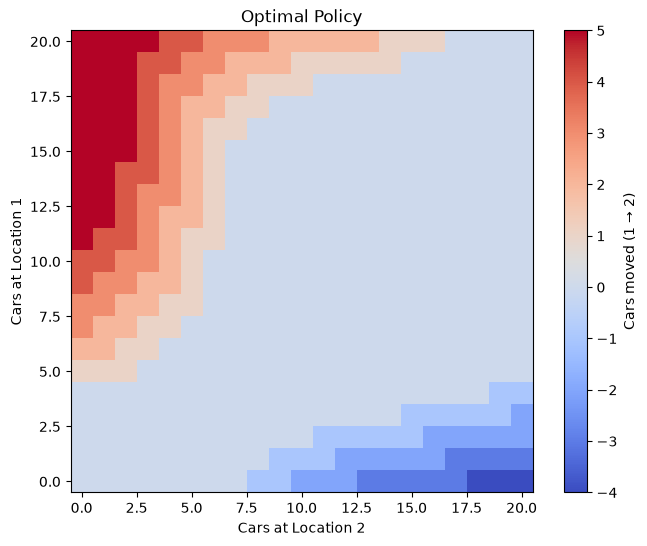

In [69]:

import matplotlib.pyplot as plt

def plot_policy(policy):
    plt.figure(figsize=(8,6))
    
    plt.imshow(policy, origin='lower', cmap='coolwarm')
    plt.colorbar(label="Cars moved (1 → 2)")
    
    plt.xlabel("Cars at Location 2")
    plt.ylabel("Cars at Location 1")
    plt.title("Optimal Policy")
    
    plt.show()

plot_policy(policy)


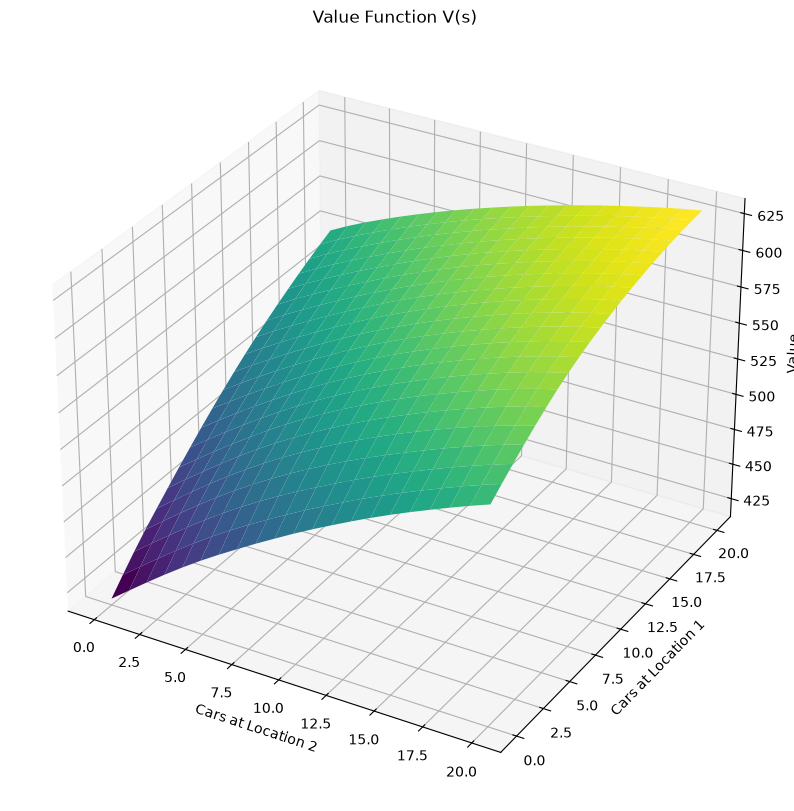

In [70]:
from mpl_toolkits.mplot3d import Axes3D

def plot_value_function(V):
    x = np.arange(0, MAX_CARS + 1)
    y = np.arange(0, MAX_CARS + 1)
    X, Y = np.meshgrid(x, y)
    
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.plot_surface(X, Y, V, cmap='viridis')
    
    ax.set_xlabel("Cars at Location 2")
    ax.set_ylabel("Cars at Location 1")
    ax.set_zlabel("Value")
    
    ax.set_title("Value Function V(s)")
    
    plt.show()

plot_value_function(V)


## Part 2

Additional Terms:

One of Arash’s employees at the first garage rides a bus home each night and lives near the second garage. He would be very happy to drive one car to the second garage for free. Still, at most 5 cars can be moved from one garage to another.

Due to heavy government taxes, if more than 10 cars are kept overnight at a garage, then an additional cost of 4 Rials must be paid.

These sorts of nonlinearities and arbitrary dynamics often
occur in real problems and cannot easily be handled by optimization methods other than
dynamic programming.

Don't forget to solve this problem by policy iteration.

In [71]:
def expected_return(state :tuple, action :int, V):

    c1, c2 = state
    c1_new = np.clip(c1 - action, 0, MAX_CARS)
    c2_new = np.clip(c2 + action, 0, MAX_CARS)
    cost = (abs(action) * MOVE_COST) - (MOVE_COST * (action > 0)) + (4 * (c1_new > 10)) + (4 * (c2_new > 10))

    r1 = np.arange(N_POISSON)
    r2 = np.arange(N_POISSON)
    e1 = np.arange(N_POISSON)
    e2 = np.arange(N_POISSON)

    p_r1 = np.array([poisson_prob(n, 3) for n in r1])
    p_r2 = np.array([poisson_prob(n, 4) for n in r2])
    p_e1 = np.array([poisson_prob(n, 3) for n in e1])
    p_e2 = np.array([poisson_prob(n, 2) for n in e2])

    rent1 = np.minimum(r1[:, None, None, None], c1_new)
    rent2 = np.minimum(r2[None, :, None, None], c2_new)
    c1_next = np.minimum(c1_new - rent1 + e1[None, None, :, None], MAX_CARS)
    c2_next = np.minimum(c2_new - rent2 + e2[None, None, None, :], MAX_CARS)

    income = (rent1 + rent2) * RENTAL_REWARD
    prob = (
        p_r1[:, None, None, None]
        * p_r2[None, :, None, None]
        * p_e1[None, None, :, None]
        * p_e2[None, None, None, :]
    )

    expected = float(np.sum(prob * (income + GAMMA * V[c1_next, c2_next]))) - cost

    return expected

In [72]:
# using V and policy arrays from privous problem for warm start and faster convergance.
policy, V = policy_iteration(V_initial=V, policy_initial=policy)

Policy Iteration step 0
evaluation done
Policy Iteration step 1
evaluation done
Policy Iteration step 2
evaluation done
Policy converged.


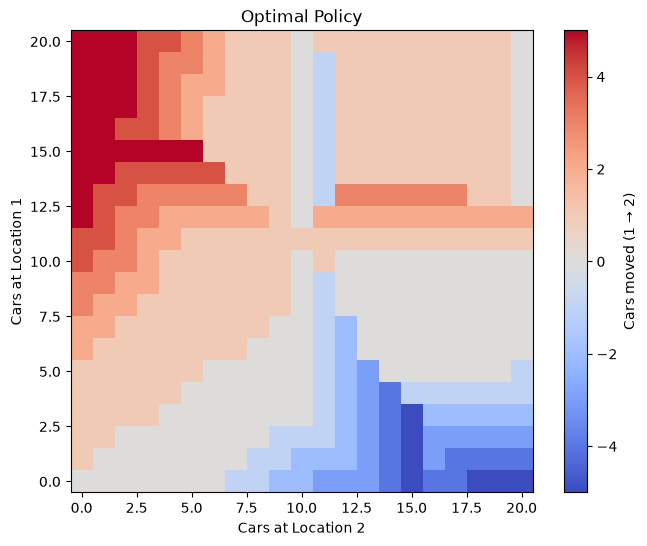

In [73]:
plot_policy(policy)

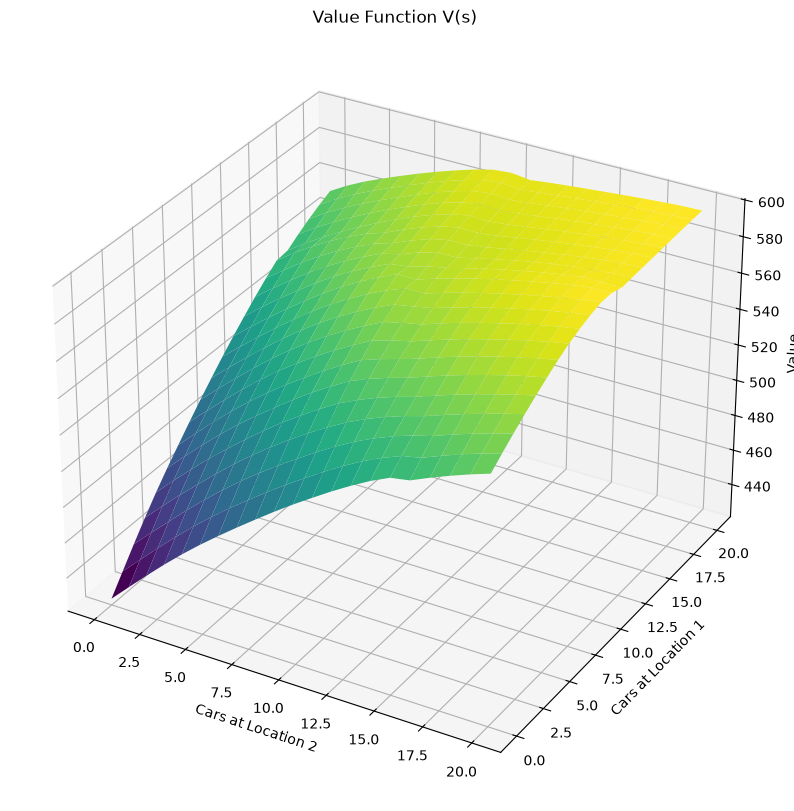

In [74]:
plot_value_function(V)

# Gambler's Problem

> "You know what date is on this coin? 1958. It's been traveling 22 years to get here, and now it's here. And it's either heads or tails, and you have to decide to call it."
>
> — Anton Chigurh, *No Country for Old Men* (2007)

A gambler has the opportunity to make bets on
the outcomes of a sequence of coin flips. If the coin comes up heads, he wins as many
dollars as he has staked on that flip; if it is tails, he loses his stake. The game ends
when the gambler wins by reaching his goal of $100, or loses by running out of money.
On each flip, the gambler must decide what portion of his capital to stake, in integer
numbers of dollars. This problem can be formulated as an undiscounted, episodic, finite
MDP.

The state is the gambler's capital, and the actions are stakes. The reward is zero on all transitions except those on which the gambler reaches his goal, when it is +1.

The state-value function then gives the probability of winning from each state. A policy is a mapping from levels of capital to stakes. The optimal policy maximizes the probability of reaching the goal.

Let $p_h$ denote the probability of the coin coming up heads. If $p_h$ is known, then the entire problem is known and it can be solved.

Implement value iteration for this problem and solve it for $p_h$ = 0.4 and $p_h$ = 0.55 and 
$p_h$ = 0.25.

Show your results graphically with plot_policy function.

In [75]:
import numpy as np

def value_iteration(num_coins, p_h, theta=1e-9, max_iter=10_000):

    V = np.zeros(num_coins + 1)
    V[num_coins] = 1.0

    for _ in range(max_iter):
        delta = 0.0

        V_new = V.copy()

        for s in range(1, num_coins):
            actions = range(1, min(s, num_coins - s) + 1)
            V_new[s] = max(p_h * V[s + a] + (1 - p_h) * V[s - a] for a in actions)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new

        if delta < theta:
            break

    # Extract optimal policy after convergence (deterministic greedy)
    policy = np.zeros(num_coins+1, dtype=int)
    for s in range(1, num_coins):
        actions = range(1, min(s, num_coins - s) + 1)
        policy[s] = max(actions, key=lambda a: p_h * V[s + a] + (1 - p_h) * V[s - a])

    return V, policy

In [76]:
import matplotlib.pyplot as plt

def plot_policy(policy):
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(policy)), policy, width=1.0)
    plt.xlabel("Capital")
    plt.ylabel("Stake")
    plt.grid(True)
    plt.show()


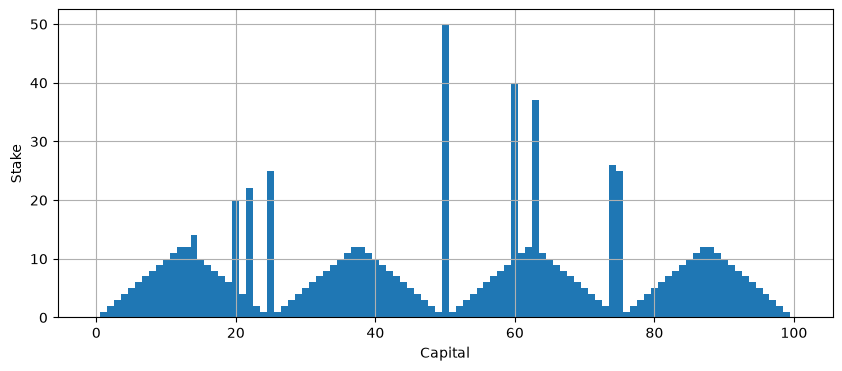

In [77]:
# Solve for p_h = 0.40
V_40, policy_40 = value_iteration(num_coins=100, p_h=0.4)
plot_policy(policy_40)

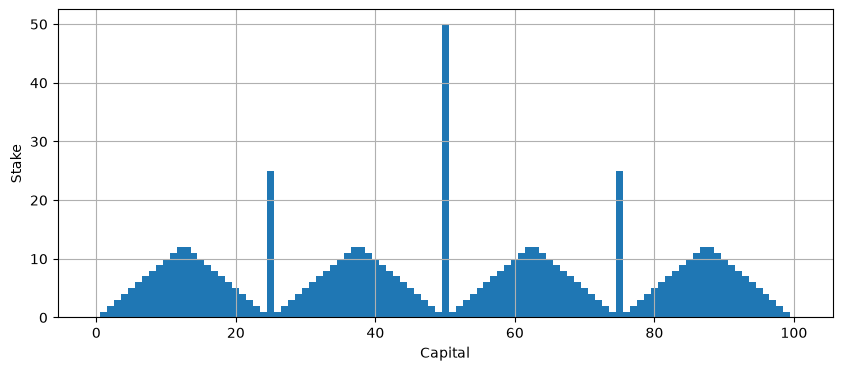

In [78]:
# Solve for p_h = 0.25
V_25, policy_25 = value_iteration(num_coins=100, p_h=0.25)
plot_policy(policy_25)


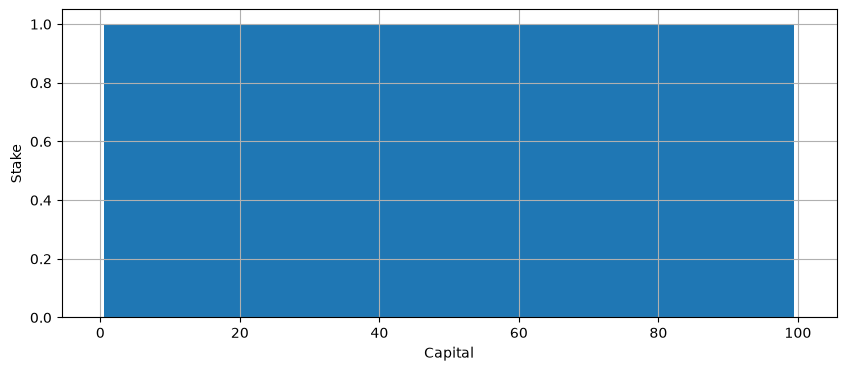

In [79]:
# Solve for p_h = 0.55
V_55, policy_55 = value_iteration(num_coins=100, p_h=0.55)
plot_policy(policy_55)


As you may notice, the optimal policy for the gambler's problem have a curious form. This policy is optimal, but **not unique**. In fact there is a whole family of optimal policies, all corresponding to ties for the argmax action selection with respect to the optimal value function.

The gambler's problem demonstrates the **Bitter Lesson** of AI: general methods that leverage computation eventually outperform methods that rely on human intuition. Value iteration made no assumptions about "reasonable" betting strategies. It simply applied the Bellman optimality equation repeatedly until convergence. The resulting policy is mathematically optimal, even though no human gambler would play that way.

This is the power (and the "bitterness") of the lesson: When you trust the algorithm to explore the full space of possibilities, it will find solutions you could never derive on your own. The weird policy is not a sign of error. It is a sign that you have discovered something truly optimal, something beyond intuition.

The gambler's problem teaches us that in a losing game, the optimal strategy isn't to play it safe; Trust the Bellman equation, not your gut.